## 0. Imports & Configuration

In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import re
import os
import warnings
import arabic_reshaper
from bidi.algorithm import get_display

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

DATA_PATH    = '../data/raw/'
FIGURES_PATH = '../results/figures/'
os.makedirs(FIGURES_PATH, exist_ok=True)

LABEL_NAMES = {1: 'Positif', 0: 'Négatif'}

print('Imports OK')

Imports OK


## 1. Chargement & Fusion

In [79]:
df_pos = pd.read_csv(DATA_PATH + 'train_pos.tsv', sep='\t', header=None)
df_neg = pd.read_csv(DATA_PATH + 'train_neg.tsv', sep='\t', header=None)
df_pos.columns = ['label_raw', 'text']
df_neg.columns = ['label_raw', 'text']

df_pos['label'] = 1
df_neg['label'] = 0

df = pd.concat([df_pos, df_neg], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
df['label_name'] = df['label'].map(LABEL_NAMES)

print(f'Total : {len(df):,} tweets')
print(f'Colonnes : {list(df.columns)}')

df.head(10)

Total : 11,520 tweets
Colonnes : ['label_raw', 'text', 'label', 'label_name']


,label_raw,text,label,label_name
0,pos,#مسابقة والجائزة 💰 / من أول من فتق لسانه بالعر...,1,Positif
1,neg,❥↓🌿🍥 ما لأبن أدم والفخر اوله نطفه وأخره جيفه و...,0,Négatif
2,pos,"✨ لاتحزن ودع القلق,يستجيب لك الكريم هو يأخرها ...",1,Positif
3,neg,بيي الله يستر طلعتي من الدوام سيارتي وايد نازل...,0,Négatif
4,neg,تلاتين سنة بترقص .. الليلة رقصتنا أنا ببكي 😭 د...,0,Négatif
5,pos,لا فض فوك بو أحمد، وصبحك الله بالخير 💐,1,Positif
6,pos,بمناسبة فوز الهلال .. 💙 سحب على آيفون XR📱 رتوي...,1,Positif
7,pos,ربي أجرني..قد أتيتك مذنبا أنت الكريم ومن تجير ...,1,Positif
8,neg,والله الثلاثة اتفه من بعض العروس كريهة شو يعني...,0,Négatif
9,pos,في كل شخص منا شيئا عظيما أوجده الله فيه ، ووضع...,1,Positif


## 2. Vue Générale

In [80]:
print(df.shape)       
print(df.info())      
df.describe(include='all')  

(11520, 4)
<class 'pandas.DataFrame'>
RangeIndex: 11520 entries, 0 to 11519
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   label_raw   11520 non-null  str  
 1   text        11520 non-null  str  
 2   label       11520 non-null  int64
 3   label_name  11520 non-null  str  
dtypes: int64(1), str(3)
memory usage: 360.1 KB
None


,label_raw,text,label,label_name
count,11520,11520,11520.000000,11520
unique,2,8817,NaN,2
top,neg,بمناسبة فوز الهلال .. 💙 سحب على آيفون XR📱 رتوي...,NaN,Négatif
freq,5768,108,NaN,5768
mean,NaN,NaN,0.499306,NaN
std,NaN,NaN,0.500021,NaN
min,NaN,NaN,0.000000,NaN
25%,NaN,NaN,0.000000,NaN
50%,NaN,NaN,0.000000,NaN
75%,NaN,NaN,1.000000,NaN


## 3. Distribution des Classes

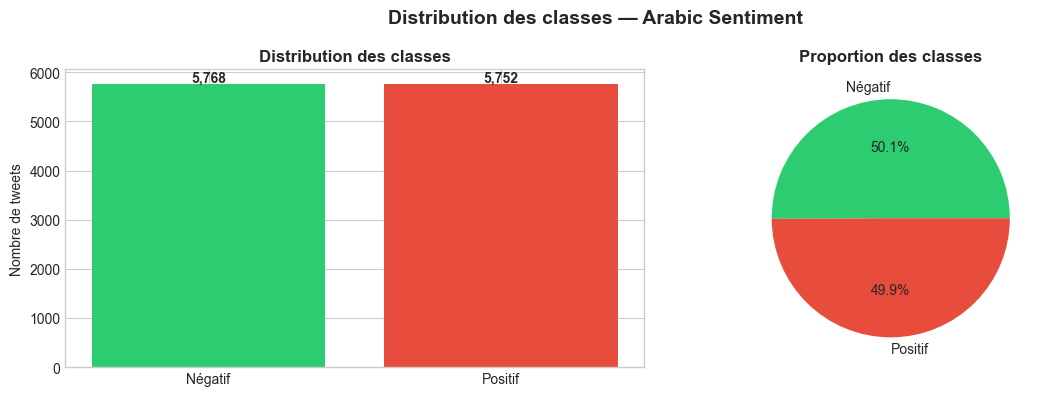

Ratio déséquilibre : 1.00x


In [81]:
label_counts = df['label'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(
    [LABEL_NAMES[k] for k in label_counts.index],
    label_counts.values,
    color=['#2ecc71', '#e74c3c']
)
axes[0].set_title('Distribution des classes', fontweight='bold')
axes[0].set_ylabel('Nombre de tweets')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(
    label_counts.values,
    labels=[LABEL_NAMES[k] for k in label_counts.index],
    autopct='%1.1f%%',
    colors=['#2ecc71', '#e74c3c']
)
axes[1].set_title('Proportion des classes', fontweight='bold')

plt.suptitle('Distribution des classes — Arabic Sentiment', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

ratio = label_counts.max() / label_counts.min()
print(f'Ratio déséquilibre : {ratio:.2f}x')

## 4. Analyse de la Longueur des Tweets

=== Statistiques longueur (mots) ===
count    11520.0
mean        13.2
std         14.0
min          3.0
25%          6.0
50%         13.0
75%         19.0
max        813.0
Name: word_count, dtype: float64


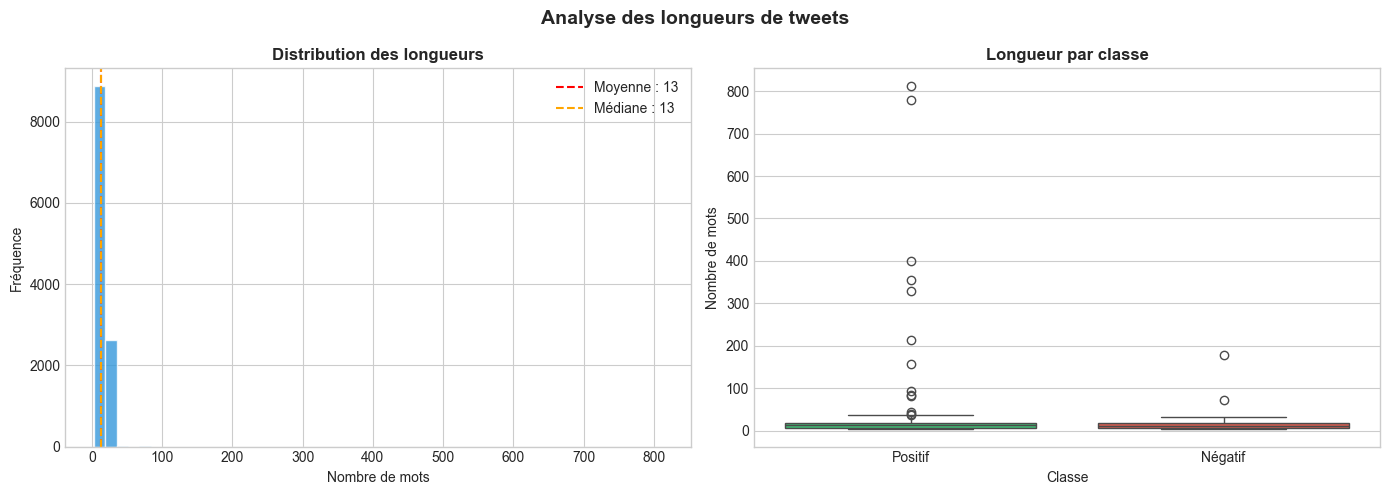

In [82]:
df['word_count'] = df['text'].astype(str).apply(lambda x: len(x.split())).astype(int)
df['char_count'] = df['text'].astype(str).apply(len)

print('=== Statistiques longueur (mots) ===')
print(df['word_count'].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme global
axes[0].hist(df['word_count'], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['word_count'].mean(), color='red', linestyle='--', label=f"Moyenne : {df['word_count'].mean():.0f}")
axes[0].axvline(df['word_count'].median(), color='orange', linestyle='--', label=f"Médiane : {df['word_count'].median():.0f}")
axes[0].set_title('Distribution des longueurs', fontweight='bold')
axes[0].set_xlabel('Nombre de mots')
axes[0].set_ylabel('Fréquence')
axes[0].legend()

# Boxplot par classe
sns.boxplot(data=df, x='label_name', y='word_count', ax=axes[1], palette=['#2ecc71', '#e74c3c'])
axes[1].set_title('Longueur par classe', fontweight='bold')
axes[1].set_xlabel('Classe')
axes[1].set_ylabel('Nombre de mots')

plt.suptitle('Analyse des longueurs de tweets', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_text_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [83]:
df.loc[df['word_count'].idxmax()]

label_raw                                                   pos
text           ﴿وجزاهم بما صبروا جنة وحريرا ﴾ على سبيل الراح...
label                                                         1
label_name                                              Positif
word_count                                                  813
char_count                                                 4049
Name: 8604, dtype: object

## 5. Qualité des Données

In [84]:
print('=== Valeurs nulles ===')
print(df.isnull().sum())

print('\n=== Tweets vides ===')
empty = df['text'].astype(str).str.strip().eq('').sum()
print(f'{empty} tweets vides')

print('\n=== Tweets dupliqués ===')
dupes = df.duplicated(subset='text').sum()
print(f'{dupes} tweets dupliqués ({dupes/len(df)*100:.1f}%)')


print(f'Tweets avec +50 mots : {(df["word_count"] > 50).sum()}')

=== Valeurs nulles ===
label_raw     0
text          0
label         0
label_name    0
word_count    0
char_count    0
dtype: int64

=== Tweets vides ===
0 tweets vides

=== Tweets dupliqués ===
2703 tweets dupliqués (23.5%)
Tweets avec +50 mots : 12


## 6. Analyse Linguistique

                 count   pct
URLs                 0   0.0
Mentions @           0   0.0
Hashtags #        1951  16.9
Emojis            4741  41.2
Lettres latines    424   3.7
Chiffres           287   2.5


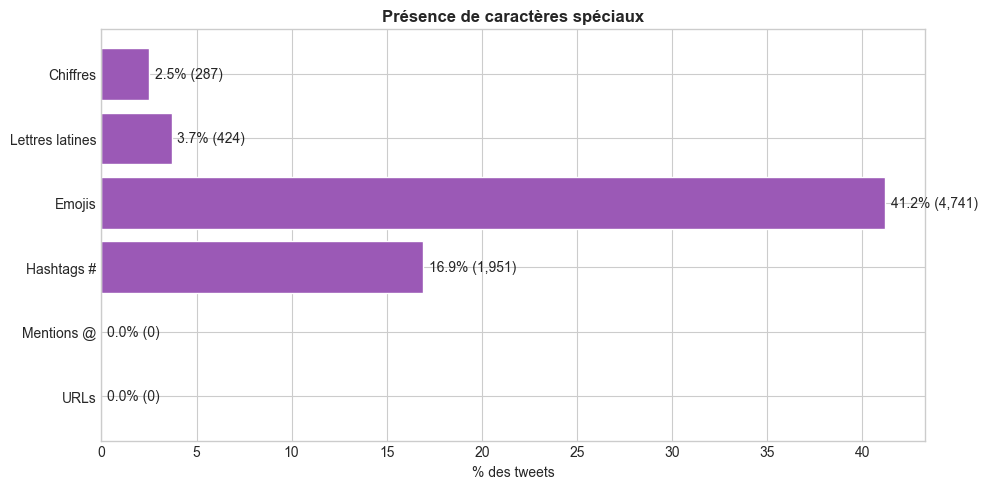

In [85]:
df['has_url']     = df['text'].str.contains(r'http\S+|www\.\S+', regex=True)
df['has_mention'] = df['text'].str.contains(r'@\w+', regex=True)
df['has_hashtag'] = df['text'].str.contains(r'#\w+', regex=True)
df['has_emoji']   = df['text'].str.contains(r'[\U0001F600-\U0001F999]', regex=True)
df['has_latin']   = df['text'].str.contains(r'[a-zA-Z]', regex=True)
df['has_numbers'] = df['text'].str.contains(r'\d', regex=True)


features = ['has_url', 'has_mention', 'has_hashtag', 'has_emoji', 'has_latin', 'has_numbers']
labels   = ['URLs', 'Mentions @', 'Hashtags #', 'Emojis', 'Lettres latines', 'Chiffres']

counts = df[features].sum()
pcts   = (counts / len(df) * 100).round(1)

summary = pd.DataFrame({'count': counts, 'pct': pcts})
summary.index = labels
print(summary.to_string())


fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(labels, pcts.values, color='#9b59b6', edgecolor='white')
for i, (pct, cnt) in enumerate(zip(pcts.values, counts.values)):
    ax.text(pct + 0.3, i, f'{pct}% ({cnt:,})', va='center', fontsize=10)
ax.set_xlabel('% des tweets')
ax.set_title('Présence de caractères spéciaux', fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_linguistic_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Word Cloud par Classe

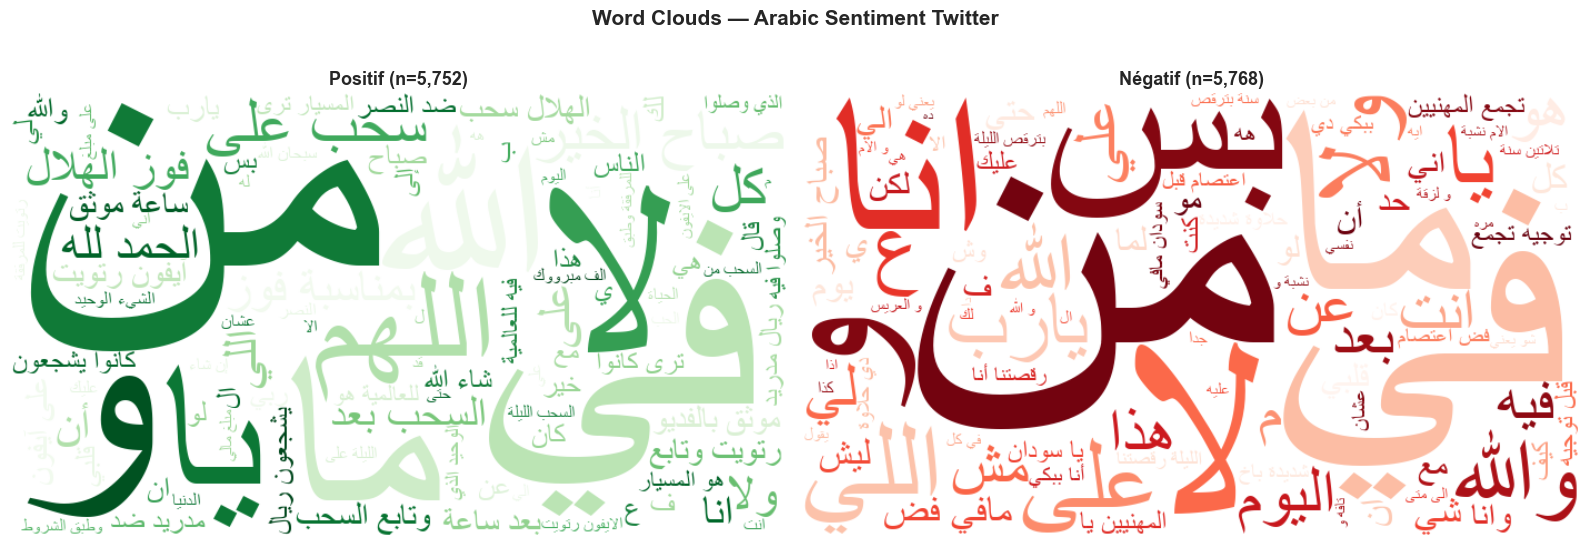

In [86]:
def prepare_arabic_text(text):
    text = re.sub(r'http\S+|@\w+|#\w+', '', str(text))
    text = re.sub(r'[^\u0600-\u06FF\s]', '', text)
    reshaped = arabic_reshaper.reshape(text)
    return get_display(reshaped)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for i, (lbl, cmap, title) in enumerate(zip([1, 0], ['Greens', 'Reds'], ['Positif', 'Négatif'])):
    corpus = ' '.join([
        prepare_arabic_text(t)
        for t in df[df['label'] == lbl]['text']
    ])
    wc = WordCloud(
        width=700, height=400,
        background_color='white',
        colormap=cmap,
        max_words=100,
        font_path='C:/Windows/Fonts/arial.ttf'
    ).generate(corpus)

    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].axis('off')
    axes[i].set_title(f'{title} (n={len(df[df["label"]==lbl]):,})', fontsize=13, fontweight='bold')

plt.suptitle('Word Clouds — Arabic Sentiment Twitter', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}ds2_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Résumé & Conclusions

In [87]:
maxlen = int(np.percentile(df['word_count'], 95))

print('=' * 55)
print('   RÉSUMÉ EDA — DATASET 2 ARABIC SENTIMENT TWITTER')
print('=' * 55)
print(f"""
DATASET
  Total tweets        : {len(df):,}
  Nombre de classes   : {df['label'].nunique()} (Positif / Négatif)
  Ratio déséquilibre  : {df['label'].value_counts().max() / df['label'].value_counts().min():.2f}x

LONGUEUR DES TWEETS
  Moyenne             : {df['word_count'].mean():.0f} mots
  Médiane             : {df['word_count'].median():.0f} mots
  Max                 : {df['word_count'].max()} mots
  → maxlen padding    : {maxlen} mots (95e percentile)

QUALITÉ
  Doublons            : {df.duplicated(subset='text').sum():,} ({df.duplicated(subset='text').mean()*100:.1f}%)
  Tweets +50 mots     : {(df['word_count'] > 50).sum()}
  Emojis              : {df['has_emoji'].sum():,} ({df['has_emoji'].mean()*100:.1f}%)
  Hashtags            : {df['has_hashtag'].sum():,} ({df['has_hashtag'].mean()*100:.1f}%)

Next step sera
  → Supprimer doublons et tweets corrompus
  → Supprimer emojis, hashtags, lettres latines
  → Normaliser les alef, supprimer tashkil + tatweel
  → Supprimer stopwords arabes
  → maxlen = {maxlen}
""")
print('=' * 55)

df.to_csv('../data/processed/ds2_eda.csv', index=False)
print('Sauvegardé : data/processed/ds2_eda.csv')

   RÉSUMÉ EDA — DATASET 2 ARABIC SENTIMENT TWITTER

DATASET
  Total tweets        : 11,520
  Nombre de classes   : 2 (Positif / Négatif)
  Ratio déséquilibre  : 1.00x

LONGUEUR DES TWEETS
  Moyenne             : 13 mots
  Médiane             : 13 mots
  Max                 : 813 mots
  → maxlen padding    : 24 mots (95e percentile)

QUALITÉ
  Doublons            : 2,703 (23.5%)
  Tweets +50 mots     : 12
  Emojis              : 4,741 (41.2%)
  Hashtags            : 1,951 (16.9%)

Next step sera
  → Supprimer doublons et tweets corrompus
  → Supprimer emojis, hashtags, lettres latines
  → Normaliser les alef, supprimer tashkil + tatweel
  → Supprimer stopwords arabes
  → maxlen = 24

Sauvegardé : data/processed/ds2_eda.csv
